Vehicle with Parallel Experiments

In [1]:
import pandas as pd
import pathlib
import incawrapper
from incawrapper import run_inca
import ast
PROJECT_DIR = pathlib.Path().cwd().parents[1].resolve()
data_folder = PROJECT_DIR / pathlib.Path("C:/Users/HP/Desktop/Master's Project/INCAWrapper")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandera\_pandas_deprecated.py:149: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


In [ ]:
tracers_data = pd.read_csv(data_folder / "tracers_multiple_exp.csv",
   converters={'atom_mdv':ast.literal_eval, 'atom_ids':ast.literal_eval} # a trick to read lists from csv
)
reactions_data = pd.read_csv(data_folder / "reactions2.csv")
ms_data = pd.read_csv(data_folder / "Vehicle_Parallel_MS.csv",
   converters={'labelled_atom_ids': ast.literal_eval} # a trick to read lists from csv
)
pool_sizes = pd.read_csv(data_folder / "vehicle_pool_sizes.csv")
flux_measurements = pd.read_csv(data_folder /"vehicle_extracellular_fluxes.csv")

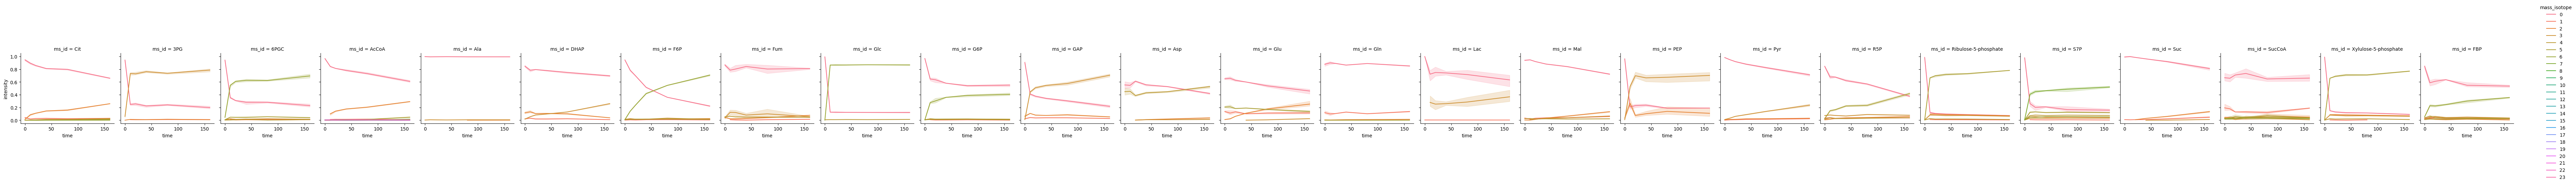

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(ms_data, col="ms_id", hue="mass_isotope")
g.map_dataframe(sns.lineplot, data=ms_data, x="time", y="intensity")

# add overall legend
g.add_legend()

In [ ]:
output_file = PROJECT_DIR / pathlib.Path("C:/Users/HP/Desktop/Master's Project/INCAWrapper/Vehicle_parallel.mat")
script = incawrapper.create_inca_script_from_data(
    reactions_data=reactions_data,
    tracer_data=tracers_data,
    flux_measurements=flux_measurements,
    pool_measurements=pool_sizes,
    ms_measurements=ms_data,
    experiment_ids=["exp1","exp2","exp3"]
)
script.add_to_block("options",
    incawrapper.define_options(
        fit_starts=20, # Number of flux estimation restarts
        sim_na=False, # Do not simulate natural abundance
        sim_ss=False # Do INST 13C MFA
    )
)
script.add_to_block("runner", incawrapper.define_runner(output_file, run_estimate=True, run_continuation=True))

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\incawrapper\core\INCAScript_writing.py:336: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ms_measurements[fill_columns] = ms_measurements[fill_columns].ffill().bfill()
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\incawrapper\core\INCAScript_writing.py:336: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ms_measurements[fill_columns] = ms_measurements[fill_columns].ffill().bfill()
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\incawrapper\co

In [5]:
import os

# Change working directory
os.chdir(r"C:/Users/HP/Desktop/Master's Project/INCAWrapper")

# Verify the change
print("Current working directory:", os.getcwd())
import os

# Change working directory
os.chdir(r"C:/Users/HP/Desktop/Master's Project/INCAWrapper")

# Verify the change
print("Current working directory:", os.getcwd())


Current working directory: C:\Users\HP\Desktop\Master's Project\INCAWrapper
Current working directory: C:\Users\HP\Desktop\Master's Project\INCAWrapper


In [6]:
# Write the INCA script to a file
script_filename = "Vehicle_parallel.m"
script.save_script(PROJECT_DIR / script_filename)
print(f"INCA script saved to {PROJECT_DIR / script_filename}.")

INCA script saved to C:\Users\HP\AppData\Local\Vehicle_parallel.m.


Go to MATLAB to run the script:
- Define molecular symmetry 
- Assign CO2 as unbalanced
- Activate Parallel Computing

In [ ]:
res = incawrapper.INCAResults(output_file)

In [ ]:
res.fitdata.get_goodness_of_fit()

In [ ]:
estimated_fluxes = res.fitdata.fitted_parameters.query("type.str.contains('flux')")
estimated_fluxes